# 3 — BLIP 시각적 질의응답

## 1. BLIP 시각적 질의응답(VQA)

VQA는 이미지와 질문을 함께 입력하고, 이미지 내용을 바탕으로 답변 텍스트를 생성하는 작업이다. 캡셔닝이 이미지 전체를 설명하는 문장을 생성한다면, VQA는 특정 질문에 초점을 맞춘 답변을 생성한다.

In [ ]:
# !uv add -q torch torchvision transformers pillow matplotlib

c:\lab\llm-workspace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


실행 장치: cpu


Loading weights: 100%|██████████| 788/788 [00:02<00:00, 274.34it/s]


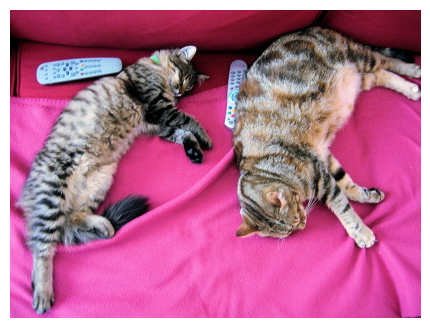

In [ ]:
# ============================================================
# BLIP VQA + NLLB 다국어 질의응답 완성 코드
# ============================================================
#
# 목표
# ------------------------------------------------------------
# 1. 영어 질문을 입력하면
#       영어 질문 → BLIP VQA → 영어 답변
#
# 2. 한국어 질문을 입력하면
#       한국어 질문
#           ↓
#       NLLB 한국어 → 영어
#           ↓
#       BLIP VQA
#           ↓
#       영어 답변
#           ↓
#       NLLB 영어 → 한국어
#           ↓
#       한국어 답변
#
# 예
# ------------------------------------------------------------
# 영어 질문:
#   What animals are in the picture?
#
# 영어 답변:
#   cats
#
#
# 한국어 질문:
#   사진에는 어떤 동물들이 있나요?
#
# 한국어 답변:
#   고양이
#
# ============================================================


# ============================================================
# 0. 필요한 패키지
# ============================================================
#
# 설치되어 있지 않다면 다음 명령을 실행한다.
#
# pip install torch transformers sentencepiece pillow matplotlib
#
# Jupyter Notebook:
#
# !pip install -U torch transformers sentencepiece pillow matplotlib
#
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import torch
import matplotlib.pyplot as plt

from PIL import Image
from urllib.request import urlopen

from transformers import (
    # --------------------------------------------------------
    # BLIP VQA
    # --------------------------------------------------------
    BlipProcessor,
    BlipForQuestionAnswering,

    # --------------------------------------------------------
    # NLLB 번역
    # --------------------------------------------------------
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
)


# ============================================================
# 2. 실행 장치 설정
# ============================================================
#
# 우선순위
#
# NVIDIA GPU
#     ↓
# Apple MPS
#     ↓
# CPU
#
# ============================================================

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"


print("=" * 60)
print("실행 장치:", device)
print("=" * 60)


# ============================================================
# 3. BLIP VQA 모델 설정
# ============================================================
#
# BLIP에는 여러 종류의 모델이 있다.
#
# 이미지 설명 생성:
#
#   Salesforce/blip-image-captioning-base
#
# 이미지 질문 답변(VQA):
#
#   Salesforce/blip-vqa-base
#
# 여기서는 이미지에 질문을 하고 답변을 생성해야 하므로
# VQA 전용 체크포인트를 사용한다.
#
# ============================================================

VQA_MODEL_NAME = "Salesforce/blip-vqa-base"


print()
print("BLIP VQA 모델 로딩 중...")


# ------------------------------------------------------------
# BLIP Processor
#
# 이미지와 질문을 모델 입력 형식으로 변환한다.
#
# 이미지
#     ↓
# pixel_values
#
# 질문
#     ↓
# input_ids
# attention_mask
#
# ------------------------------------------------------------

processor = BlipProcessor.from_pretrained(
    VQA_MODEL_NAME
)


# ------------------------------------------------------------
# BLIP VQA 모델
# ------------------------------------------------------------

model = BlipForQuestionAnswering.from_pretrained(
    VQA_MODEL_NAME
)


# ------------------------------------------------------------
# 모델을 실행 장치로 이동
# ------------------------------------------------------------

model = model.to(device)


# ------------------------------------------------------------
# 평가 모드
#
# Dropout 등의 학습용 동작을 비활성화한다.
# ------------------------------------------------------------

model.eval()


print("BLIP VQA 모델 로딩 완료")


# ============================================================
# 4. NLLB 번역 모델 설정
# ============================================================
#
# BLIP VQA는 기본적으로 영어 중심 모델이다.
#
# 따라서 한국어 질문을 직접 BLIP에 전달하지 않고
#
# 한국어 → 영어
#
# 로 번역한 후 BLIP에 전달한다.
#
#
# BLIP의 영어 답변도
#
# 영어 → 한국어
#
# 로 번역하여 사용자에게 보여준다.
#
#
# 사용 모델:
#
# facebook/nllb-200-distilled-600M
#
# 언어 코드:
#
# 한국어 = kor_Hang
# 영어   = eng_Latn
#
# ============================================================

TRANSLATION_MODEL_NAME = (
    "facebook/nllb-200-distilled-600M"
)


print()
print("NLLB 번역 모델 로딩 중...")


# ------------------------------------------------------------
# NLLB Tokenizer
# ------------------------------------------------------------

translator_tokenizer = AutoTokenizer.from_pretrained(
    TRANSLATION_MODEL_NAME
)


# ------------------------------------------------------------
# NLLB 번역 모델
# ------------------------------------------------------------

translator_model = (
    AutoModelForSeq2SeqLM.from_pretrained(
        TRANSLATION_MODEL_NAME
    )
)


# ------------------------------------------------------------
# 실행 장치로 이동
# ------------------------------------------------------------

translator_model = translator_model.to(
    device
)


# ------------------------------------------------------------
# 평가 모드
# ------------------------------------------------------------

translator_model.eval()


print("NLLB 번역 모델 로딩 완료")


# ============================================================
# 5. 한글 포함 여부 검사 함수
# ============================================================

def contains_korean(text):
    """
    문자열에 한글이 포함되어 있는지 확인한다.

    반환
    ----------------------------------------------------------
    True
        한글 포함

    False
        한글 없음


    예
    ----------------------------------------------------------

    contains_korean(
        "고양이가 몇 마리 보이나요?"
    )

    → True


    contains_korean(
        "How many cats are visible?"
    )

    → False
    """

    return any(
        "\uac00" <= char <= "\ud7a3"
        for char in text
    )


# ============================================================
# 6. NLLB 언어 Token ID를 구하는 함수
# ============================================================

def get_language_token_id(
    tokenizer,
    language_code,
):
    """
    NLLB 목표 언어 Token ID를 반환한다.

    Transformers 버전에 따라
    lang_code_to_id 속성의 존재 여부가 다를 수 있으므로
    두 가지 방식을 지원한다.

    예
    ----------------------------------------------------------

    kor_Hang
        → 한국어 Token ID

    eng_Latn
        → 영어 Token ID
    """

    # --------------------------------------------------------
    # 방법 1
    # --------------------------------------------------------

    if hasattr(
        tokenizer,
        "lang_code_to_id"
    ):

        lang_code_to_id = (
            tokenizer.lang_code_to_id
        )

        if (
            lang_code_to_id is not None
            and language_code
            in lang_code_to_id
        ):

            return (
                lang_code_to_id[
                    language_code
                ]
            )


    # --------------------------------------------------------
    # 방법 2
    #
    # 언어 코드 문자열을 직접 Token ID로 변환한다.
    # --------------------------------------------------------

    token_id = (
        tokenizer.convert_tokens_to_ids(
            language_code
        )
    )


    # --------------------------------------------------------
    # 정상적인 ID인지 확인한다.
    # --------------------------------------------------------

    if token_id is None:

        raise ValueError(
            "NLLB 언어 코드를 찾을 수 없습니다: "
            f"{language_code}"
        )


    return token_id


# ============================================================
# 7. NLLB 공통 번역 함수
# ============================================================

def translate_text(
    text,
    source_language,
    target_language,
):
    """
    NLLB를 이용하여 문장을 번역한다.

    Parameters
    ----------------------------------------------------------

    text
        번역할 문자열

    source_language
        입력 언어 코드

    target_language
        출력 언어 코드


    언어 코드
    ----------------------------------------------------------

    한국어
        kor_Hang

    영어
        eng_Latn


    예 1
    ----------------------------------------------------------

    한국어 → 영어

    translate_text(
        "고양이가 몇 마리 보이나요?",
        "kor_Hang",
        "eng_Latn"
    )


    예 2
    ----------------------------------------------------------

    영어 → 한국어

    translate_text(
        "cats",
        "eng_Latn",
        "kor_Hang"
    )
    """

    # --------------------------------------------------------
    # 1. 문자열 정리
    # --------------------------------------------------------

    text = text.strip()


    if not text:

        return ""


    # --------------------------------------------------------
    # 2. 입력 언어 설정
    #
    # 매우 중요하다.
    #
    # 한국어 입력
    #
    #     kor_Hang
    #
    # 영어 입력
    #
    #     eng_Latn
    #
    # --------------------------------------------------------

    translator_tokenizer.src_lang = (
        source_language
    )


    # --------------------------------------------------------
    # 3. 문자열 → Token
    # --------------------------------------------------------

    inputs = translator_tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    )


    # --------------------------------------------------------
    # 4. Tensor를 모델 실행 장치로 이동
    # --------------------------------------------------------

    inputs = {
        key: value.to(device)
        for key, value
        in inputs.items()
    }


    # --------------------------------------------------------
    # 5. 목표 언어 ID
    #
    # NLLB에서는 출력 언어를 명확하게 지정해야 한다.
    #
    # 예:
    #
    # 영어
    #     eng_Latn
    #
    # 한국어
    #     kor_Hang
    #
    # --------------------------------------------------------

    target_language_id = (
        get_language_token_id(
            translator_tokenizer,
            target_language,
        )
    )


    # --------------------------------------------------------
    # 6. 번역 실행
    #
    # forced_bos_token_id
    #
    # NLLB가 어떤 언어로 문장을 생성할 것인지
    # 강제로 지정한다.
    # --------------------------------------------------------

    with torch.inference_mode():

        generated_ids = (
            translator_model.generate(
                **inputs,

                forced_bos_token_id=(
                    target_language_id
                ),

                max_new_tokens=64,

                num_beams=4,
            )
        )


    # --------------------------------------------------------
    # 7. Token → 문자열
    # --------------------------------------------------------

    translated_text = (
        translator_tokenizer.decode(
            generated_ids[0],
            skip_special_tokens=True,
        )
    )


    return translated_text.strip()


# ============================================================
# 8. 한국어 → 영어 번역
# ============================================================

def translate_ko_to_en(text):
    """
    한국어 질문을 영어 질문으로 번역한다.

    예
    ----------------------------------------------------------

    고양이가 몇 마리 보이나요?

            ↓

    How many cats are visible?
    """

    return translate_text(
        text=text,
        source_language="kor_Hang",
        target_language="eng_Latn",
    )


# ============================================================
# 9. 영어 → 한국어 번역
# ============================================================

def translate_en_to_ko(text):
    """
    BLIP이 생성한 영어 답변을
    한국어로 번역한다.

    예
    ----------------------------------------------------------

    cats
        ↓
    고양이

    couch
        ↓
    소파
    """

    return translate_text(
        text=text,
        source_language="eng_Latn",
        target_language="kor_Hang",
    )


# ============================================================
# 10. BLIP VQA 함수
# ============================================================

def answer_blip_vqa(
    input_image,
    english_question,
    max_new_tokens=20,
):
    """
    이미지와 영어 질문을 BLIP VQA에 전달하여
    영어 답변을 생성한다.


    처리 과정
    ----------------------------------------------------------

    이미지 + 영어 질문
            ↓
       BlipProcessor
            ↓
       BLIP VQA
            ↓
        영어 답변


    예
    ----------------------------------------------------------

    이미지
        고양이 2마리가 소파에 있음

    질문
        How many cats are visible?

    답변
        2
    """

    # --------------------------------------------------------
    # 1. 이미지 형식 통일
    # --------------------------------------------------------

    input_image = input_image.convert(
        "RGB"
    )


    # --------------------------------------------------------
    # 2. 이미지 + 질문 전처리
    # --------------------------------------------------------

    model_inputs = processor(
        images=input_image,
        text=english_question,
        return_tensors="pt",
    )


    # --------------------------------------------------------
    # 3. 입력 Tensor를 BLIP 실행 장치로 이동
    # --------------------------------------------------------

    model_inputs = {
        key: value.to(device)
        for key, value
        in model_inputs.items()
    }


    # --------------------------------------------------------
    # 4. 답변 생성
    # --------------------------------------------------------

    with torch.inference_mode():

        answer_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
        )


    # --------------------------------------------------------
    # 5. Token → 문자열
    # --------------------------------------------------------

    answer = processor.decode(
        answer_ids[0],
        skip_special_tokens=True,
    )


    return answer.strip()


# ============================================================
# 11. 영어/한국어 자동 처리 VQA 함수
# ============================================================

def answer_image_question(
    input_image,
    question,
    max_new_tokens=20,
):
    """
    영어 질문과 한국어 질문을 자동으로 구분하여 처리한다.


    ==========================================================
    영어 질문
    ==========================================================

    영어 질문
        ↓
    BLIP VQA
        ↓
    영어 답변


    ==========================================================
    한국어 질문
    ==========================================================

    한국어 질문
        ↓
    NLLB
    한국어 → 영어
        ↓
    영어 질문
        ↓
    BLIP VQA
        ↓
    영어 답변
        ↓
    NLLB
    영어 → 한국어
        ↓
    한국어 답변


    반환값
    ----------------------------------------------------------

    {
        "language": "ko" 또는 "en",

        "original_question":
            사용자가 입력한 질문,

        "blip_question":
            실제 BLIP에 입력한 영어 질문,

        "english_answer":
            BLIP이 생성한 영어 답변,

        "final_answer":
            사용자에게 보여줄 최종 답변
    }
    """

    # ========================================================
    # 한국어 질문인 경우
    # ========================================================

    if contains_korean(
        question
    ):

        # ----------------------------------------------------
        # STEP 1
        #
        # 한국어 질문 → 영어 질문
        # ----------------------------------------------------

        english_question = (
            translate_ko_to_en(
                question
            )
        )


        # ----------------------------------------------------
        # STEP 2
        #
        # 영어 질문 → BLIP VQA
        # ----------------------------------------------------

        english_answer = (
            answer_blip_vqa(
                input_image=input_image,
                english_question=(
                    english_question
                ),
                max_new_tokens=(
                    max_new_tokens
                ),
            )
        )


        # ----------------------------------------------------
        # STEP 3
        #
        # 영어 답변 → 한국어 답변
        # ----------------------------------------------------

        korean_answer = (
            translate_en_to_ko(
                english_answer
            )
        )


        # ----------------------------------------------------
        # 결과 반환
        # ----------------------------------------------------

        return {

            "language":
                "ko",

            "original_question":
                question,

            "blip_question":
                english_question,

            "english_answer":
                english_answer,

            "final_answer":
                korean_answer,
        }


    # ========================================================
    # 영어 질문인 경우
    # ========================================================

    else:

        # ----------------------------------------------------
        # 번역 과정 없이
        # 영어 질문을 바로 BLIP에 전달한다.
        # ----------------------------------------------------

        english_answer = (
            answer_blip_vqa(
                input_image=input_image,
                english_question=question,
                max_new_tokens=(
                    max_new_tokens
                ),
            )
        )


        return {

            "language":
                "en",

            "original_question":
                question,

            "blip_question":
                question,

            "english_answer":
                english_answer,

            "final_answer":
                english_answer,
        }


# ============================================================
# 12. 예제 이미지 다운로드
# ============================================================
#
# COCO 이미지
#
# 고양이 두 마리가 소파 위에 있는 이미지이다.
#
# ============================================================

IMAGE_URL = (
    "http://images.cocodataset.org/"
    "val2017/000000039769.jpg"
)


try:

    with urlopen(
        IMAGE_URL,
        timeout=20,
    ) as response:

        image = Image.open(
            response
        ).convert("RGB")


except Exception as exc:

    raise RuntimeError(
        "예제 이미지 다운로드에 실패했습니다.\n"
        "인터넷 연결을 확인하거나 다음과 같이 "
        "로컬 이미지로 변경하십시오.\n\n"
        "image = Image.open('./image/cat.jpg').convert('RGB')"
    ) from exc


# ============================================================
# 13. 이미지 출력
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.imshow(
    image
)

plt.title(
    "VQA Test Image"
)

plt.axis(
    "off"
)

plt.show()


# ============================================================
# 14. 영어 질문
# ============================================================

english_questions = [

    "What animals are in the picture?",

    "Where are the animals sitting?",

    "How many cats are visible?",
]


# ============================================================
# 15. 영어 질문 → 영어 답변
# ============================================================

print()
print("=" * 70)
print("영어 질문 → 영어 답변")
print("=" * 70)


for question in english_questions:

    result = answer_image_question(
        input_image=image,
        question=question,
    )


    print(
        "질문:",
        result["original_question"]
    )


    print(
        "답변:",
        result["final_answer"]
    )


    print(
        "-" * 70
    )


# ============================================================
# 16. 한국어 질문
# ============================================================

korean_questions = [

    "사진에는 어떤 동물들이 있나요?",

    "동물들은 어디에 앉아 있나요?",

    "고양이가 몇 마리 보이나요?",
]


# ============================================================
# 17. 한국어 질문 → 한국어 답변
# ============================================================

print()
print("=" * 70)
print("한국어 질문 → 한국어 답변")
print("=" * 70)


for question in korean_questions:

    result = answer_image_question(
        input_image=image,
        question=question,
    )


    print( "질문:", result["original_question"] )


    print( "답변:", result["final_answer"] )


    print("-" * 70 )


# ============================================================
# 18. 한국어 질문의 내부 처리 과정 확인
# ============================================================
#
# 교육에서는 이 부분을 보여주면
# "BLIP이 한국어를 직접 처리한 것인가?"
# 를 명확하게 구분할 수 있다.
#
# ============================================================

print()
print("=" * 70)
print("한국어 질문 내부 처리 과정")
print("=" * 70)


for question in korean_questions:

    result = answer_image_question(
        input_image=image,
        question=question,
    )


    print( "[사용자 한국어 질문]" )

    print(result["original_question"] )


    print()
    print("[NLLB 번역 → BLIP에 실제 입력된 영어 질문]")
    print(result["blip_question"] )
    print()
    print( "[BLIP 영어 답변]" )
    print( result["english_answer"]  )
    print()
    print( "[NLLB 번역 → 최종 한국어 답변]"  )
    print( result["final_answer"] )
    print( "=" * 70 )

## 2. 질문 유형별 결과 분석

VQA 결과는 질문 유형에 따라 정확도가 달라질 수 있다.

- 객체 확인: 이미지에 어떤 사물이나 동물이 있는가?
- 속성 확인: 사물의 색상이나 크기는 무엇인가?
- 행동 확인: 사람이 무엇을 하고 있는가?
- 수량 확인: 객체가 몇 개 있는가?
- 공간 관계: 객체가 어디에 있는가?

특히 수량 계산이나 작은 객체 인식은 부정확할 수 있으므로 생성된 답변을 사실로 간주하지 않고 원본 이미지와 비교한다.

## 3. 캡셔닝과 VQA 비교 실습

동일한 이미지에 대해 먼저 캡셔닝을 실행한 다음, 구체적인 질문을 3개 이상 작성해 VQA를 실행한다.

| 비교 항목 | 이미지 캡셔닝 | VQA |
|---|---|---|
| 입력 | 이미지 | 이미지 + 질문 |
| 출력 | 전체 장면을 설명하는 문장 | 질문에 대한 답변 |
| 평가 | 장면 설명의 정확성 | 질문별 답변의 정확성 |



### 실습 과제
- 이미지 3장에 대해 질문을 각각 5개 작성한다.
- 답변이 정확한지 사람이 평가한다.
- 틀린 답변을 객체 인식, 수량, 공간 관계, 질문 모호성 등으로 분류한다.

In [1]:
# ============================================================
# BLIP VQA 실습
#
# 과제
# 1. 이미지 3장을 준비한다.
# 2. 이미지마다 질문을 5개 작성한다.
# 3. BLIP VQA로 답변을 생성한다.
# 4. 결과를 출력한다.
# 5. 사람이 직접 정답/오답을 평가한다.
# ============================================================

import torch
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. VQA 함수
# ------------------------------------------------------------

def answer_image_question(
    input_image,
    question,
    max_new_tokens=20
):
    """
    이미지와 영어 질문을 입력받아
    BLIP VQA 모델의 답변을 반환한다.
    """

    # 이미지 + 질문을 모델 입력 형식으로 변환한다.
    model_inputs = processor(
        images=input_image.convert("RGB"),
        text=question,
        return_tensors="pt"
    )

    # 모델이 실행되는 장치로 이동한다.
    model_inputs = {
        key: value.to(device)
        for key, value in model_inputs.items()
    }

    # 추론에서는 기울기를 계산할 필요가 없다.
    with torch.no_grad():

        answer_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens
        )

    # 생성된 Token ID를 문자열로 변환한다.
    answer = processor.decode(
        answer_ids[0],
        skip_special_tokens=True
    )

    return answer.strip()


# ============================================================
# 2. 실습에 사용할 이미지 3장
# ============================================================
#
# images에는 PIL Image 객체가 들어있다고 가정한다.
#
# 예:
#
images = [    
    Image.open('image/cat.jpg').convert("RGB"),
    Image.open('image/dog.jpg').convert("RGB"),
    Image.open('image/car.jpg').convert("RGB"),
]
#
# ============================================================

test_images = [
    images[0],       # car
    images[1],       # cat
    images[2]        # dog
]


# ============================================================
# 3. 이미지별 질문 5개
# ============================================================
#
# 질문은 서로 다른 능력을 평가하도록 작성한다.
#
# ① 객체 인식
# ② 수량
# ③ 공간 관계
# ④ 속성
# ⑤ 행동/상태
#
# 실제 이미지 내용에 맞게 질문을 수정한다.
# ============================================================

questions = [

    # --------------------------------------------------------
    # Image 1
    # --------------------------------------------------------

    [
        "What animals are in the picture?",
        "How many animals are visible?",
        "Where are the animals?",
        "What color are the animals?",
        "What are the animals doing?"
    ],


    # --------------------------------------------------------
    # Image 2
    # --------------------------------------------------------

    [
        "What object is in the picture?",
        "How many objects are visible?",
        "Where is the object?",
        "What color is the object?",
        "What is happening in the picture?"
    ],


    # --------------------------------------------------------
    # Image 3
    # --------------------------------------------------------

    [
        "What is the main object in the picture?",
        "How many main objects are visible?",
        "Where is the main object located?",
        "What color is the main object?",
        "What is the main object doing?"
    ]
]


# ============================================================
# 4. VQA 실행
# ============================================================

results = []


for image_index, image in enumerate(test_images):

    print()
    print("=" * 70)
    print(f"IMAGE {image_index + 1}")
    print("=" * 70)

    # 현재 이미지 출력
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Image {image_index + 1}")
    plt.show()


    # --------------------------------------------------------
    # 현재 이미지에 대한 질문 5개 실행
    # --------------------------------------------------------

    for question_index, question in enumerate(
        questions[image_index],
        start=1
    ):

        answer = answer_image_question( image, question)


        # 결과 저장
        results.append({
            "image":image_index + 1,
            "question_number": question_index,
            "question": question,
            "answer": answer
        })


        # 결과 출력
        print( f"Q{question_index}:",  question )
        print("BLIP:", answer)
        print("-" * 70)

NameError: name 'Image' is not defined

질문이 한글일 때 - 오랜시간이 걸림

In [ ]:
# ============================================================
# Qwen2.5-VL 모델 로딩

# ============================================================

import torch

from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor
)


# ------------------------------------------------------------
# 1. 모델 이름
# ------------------------------------------------------------

MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"


# ------------------------------------------------------------
# 2. 실행 장치 선택
# ------------------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

print("사용 장치:", device)


# ------------------------------------------------------------
# 3. Processor 로딩
# ------------------------------------------------------------

processor = AutoProcessor.from_pretrained(
    MODEL_NAME
)


# ------------------------------------------------------------
# 4. 모델 로딩
# ------------------------------------------------------------

# ------------------------------------------------------------

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto"
)


# ------------------------------------------------------------
# 5. 모델을 GPU 또는 CPU로 이동
# ------------------------------------------------------------

model = model.to(device)


# ------------------------------------------------------------
# 6. 추론 모드
# ------------------------------------------------------------

model.eval()

print("=" * 60)
print("모델 로딩 완료")
print("Model :", MODEL_NAME)
print("Device:", device)
print("=" * 60)

사용 장치: cpu


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]c:\lab\llm-workspace\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
